In [260]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import sharpy.utils.plotutils as pu

In [261]:
speed = 35 
u_inf = speed #m/s
alpha_deg = 4
rho = 1.225

number_chordwise_panels = 8
number_spanwise_nodes = 16
wake_length_factor = 10

cases_folder = './cases/' # folder to store input files
output_folder = './output' # folder to save results
route_notebook_dir =  os.path.abspath('')

In [262]:
case_name = "Static_Thicker"
route_test_dir = os.path.abspath('')

length = 1.2
width = 0.06
height = 0.004
c_ref= 0.2
massperunit = 1.8
massweight = 0.1

pazy_altered = wings.PazyControlSurface(
    M = number_chordwise_panels,
    N = number_spanwise_nodes,
    Mstar_fact=10,
    u_inf=u_inf,
    alpha=alpha_deg,
    cs_deflection=[0,0],
    n_control_surfaces=2,
    rho=rho,
    tip_rod=False,
    b_ref=2.*length,
    main_chord=c_ref,
    pct_flap=0.2,
    aspect_ratio=2*length/c_ref,
    n_surfaces=2,
    physical_time=2,
    route = cases_folder + '/' + case_name,
    case_name=case_name,
    #physical_time = simulation_time,
)

In [263]:
def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = massperunit
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

    n_lumped_mass = 2
    self.lumped_mass = np.zeros((n_lumped_mass))
    self.lumped_mass_position = np.zeros((n_lumped_mass, 3))
    self.lumped_mass_inertia = np.zeros((n_lumped_mass, 3, 3))
    self.lumped_mass_nodes = np.zeros((n_lumped_mass), dtype=int)

    #positive y is towards back
    self.lumped_mass[0] = massweight
    self.lumped_mass_position[0] = np.array([0, 0.5, 0])
    self.lumped_mass_nodes[0] = self.N//2
    self.lumped_mass_inertia[0, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.lumped_mass[1] = massweight
    self.lumped_mass_position[1] = np.array([0, 0.5, 0])
    self.lumped_mass_nodes[1] = self.N//2+1
    self.lumped_mass_inertia[1, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.main_ea = 0.33
    self.main_cg = 0.43

pazy_altered.update_mass_stiff = new_update_mass_stiff.__get__(pazy_altered, wings.PazyControlSurface) 

In [264]:
pazy_altered.clean_test_files()
pazy_altered.update_derived_params()
pazy_altered.set_default_config_dict()

pazy_altered.generate_aero_file()
pazy_altered.generate_fem_file()

3.2e-10
7.2e-08
[[1.656e+07 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 6.240e+06 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 6.240e+06 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 6.656e+01 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.208e+01 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 4.968e+03]]
7.232e-08
0.000195264


In [265]:
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

pazy_altered.config['SHARPy'] = {
    'flow':
        ['BeamLoader', 'AerogridLoader',
         'StaticCoupled',
         'AerogridPlot',
         'BeamPlot',
         'Modal',
         'LinearAssembler',
         'AsymptoticStability',
         ],
    'case': pazy_altered.case_name, 'route': pazy_altered.route,
    'write_screen': 'on', 'write_log': 'on',    # Change to 'on' as neded.
    'log_folder': route_test_dir + '/output/',
    'log_file': pazy_altered.case_name + '.log'
}

pazy_altered.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': pazy_altered.quat}

pazy_altered.config['AerogridLoader'] = {
    'unsteady': 'off',
    'aligned_grid': 'on',
    'mstar': pazy_altered.Mstar_fact * pazy_altered.M,
    'freestream_dir': pazy_altered.u_inf_direction,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {'u_inf': pazy_altered.u_inf,
                                    'u_inf_direction': pazy_altered.u_inf_direction,
                                    'dt': pazy_altered.dt}}

pazy_altered.config['StaticCoupled'] = {
    'print_info': 'on',
    'max_iter': 200,
    'n_load_steps': 1,
    'tolerance': 1e-10,
    'relaxation_factor': 0.,
    'aero_solver': 'StaticUvlm',
    'aero_solver_settings': {
        'rho': pazy_altered.rho,
        'print_info': 'off',
        'horseshoe': 'off',
        'num_cores': 4,
        'n_rollup': 0,
        'rollup_dt': pazy_altered.dt,
        'rollup_aic_refresh': 1,
        'rollup_tolerance': 1e-4,
        'velocity_field_generator': 'SteadyVelocityField',
        'velocity_field_input': {
            'u_inf': pazy_altered.u_inf,
            'u_inf_direction': pazy_altered.u_inf_direction}},
    'structural_solver': 'NonLinearStatic',
    'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 150,
                                   'num_load_steps': 4,
                                   'delta_curved': 1e-1,
                                   'min_delta': 1e-10,
                                   'gravity_on': 'on',
                                   'gravity': 9.81}}

pazy_altered.config['AerogridPlot'] = {'include_rbm': 'off',
                             'include_applied_forces': 'on',
                             'minus_m_star': 0}

pazy_altered.config['BeamPlot'] = {'include_rbm': 'off',
                         'include_applied_forces': 'on'}

pazy_altered.config['Modal'] = {'NumLambda': 20,
                      'rigid_body_modes': 'off',
                      'print_matrices': 'on', # 'keep_linear_matrices': 'on',            'write_dat': 'off',
                      'rigid_modes_cg': 'off',
                      'continuous_eigenvalues': 'off',
                      'dt': 0,
                      'plot_eigenvalues': False,
                      'max_rotation_deg': 15.,
                      'max_displacement': 0.15,
                      'write_modes_vtk': True,
                      'use_undamped_modes': True}

pazy_altered.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': 'on',
                                                      'inout_coords': 'modes',
                                                      'discrete_time': 'on',
                                                      'newmark_damp': 0.5e-4,
                                                      'discr_method': 'newmark',
                                                      'dt': pazy_altered.dt,
                                                      'proj_modes': 'undamped',
                                                      'use_euler': 'off',
                                                      'num_modes': 20,
                                                      'print_info': 'on',
                                                      'gravity': 'on',
                                                      'remove_sym_modes': 'on',
                                                      'remove_dofs': []},
                                    'aero_settings': {'dt': pazy_altered.dt,
                                                      'ScalingDict': {'length': 0.5 * pazy_altered.c_ref,
                                                                      'speed': u_inf,
                                                                      'density': rho},
                                                      'integr_order': 2,
                                                      'density': pazy_altered.rho,
                                                      'remove_predictor': 'on',
                                                      'use_sparse': 'on',
                                                      'remove_inputs': ['u_gust'],
                                                      'rom_method': ['Krylov'],
                                                      'rom_method_settings': {'Krylov': rom_settings}},
                                    }}

pazy_altered.config['AsymptoticStability'] = {'print_info': True,
                                    'velocity_analysis': [10, 60, 81],
                                   'modes_to_plot': []}
                                    

pazy_altered.config.write()

In [266]:
sharpy_output = sharpy.sharpy_main.main(['', pazy_altered.route + pazy_altered.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/password/sharpy/sharpy
SHARPy being run is in /home/password/.local/lib/python3.10/site-packages
SHARPy output folder set
	/home/password/sharpy/sharpy/output//

fatal: not a git repository (or any of the parent directories): .git


|  2  |  0  |  -3.82636  | -4.2108  |  0.0047  | 77.7817  | -0.0035  |  0.7059  | -0.0005  |
|  3  |  0  |  -4.65580  | -4.1986  |  0.0054  | 77.7007  | -0.0040  |  0.7074  | -0.0005  |
|  4  |  0  |  -5.47140  | -4.2005  |  0.0053  | 77.7131  | -0.0039  |  0.7072  | -0.0005  |
|  5  |  0  |  -6.28878  | -4.2002  |  0.0053  | 77.7112  | -0.0039  |  0.7072  | -0.0005  |
|  6  |  0  |  -7.10595  | -4.2002  |  0.0053  | 77.7115  | -0.0039  |  0.7072  | -0.0005  |
|  7  |  0  |  -7.92318  | -4.2002  |  0.0053  | 77.7115  | -0.0039  |  0.7072  | -0.0005  |
|  8  |  0  |  -8.74081  | -4.2002  |  0.0053  | 77.7115  | -0.0039  |  0.7072  | -0.0005  |
|  9  |  0  |  -9.56071  | -4.2002  |  0.0053  | 77.7115  | -0.0039  |  0.7072  | -0.0005  |
| 10  |  0  | -10.39451  | -4.2002  |  0.0053  | 77.7115  | -0.0039  |  0.7072  | -0.0005  |
Generating an instance of AerogridPlot
Variable include_forward_motion has no assigned value in the settings file.
    will default to the value: False
Variable in

/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning:

Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.



	state-space model produced in form:
			h_{n+1} = A h_{n} + B u_{n}
			with:
	x_n = h_n + Bp u_n
			...done in 0.75 sec
Scaling UVLM system with reference time 0.002857s
Non-dimensional time step set (0.250000)
System scaled in 0.422347s
Generating an instance of LinearBeam
Variable remove_rigid_states has no assigned value in the settings file.
    will default to the value: False
Warning, projecting system with damping onto undamped modes

Linearising gravity terms...
	M = 0.00 kg
	X_CG A -> -3.59 2.27 0.00
Node  1 	-> B -0.000 -0.000 -0.000
			-> A 0.000 0.150 0.010
			-> G 0.001 0.150 0.010
	Node mass:
		Matrix: 0.2880
Node  2 	-> B -0.000 -0.000 -0.000
			-> A 0.000 0.297 0.037
			-> G 0.003 0.297 0.036
	Node mass:
		Matrix: 0.1440
Node  3 	-> B -0.000 -0.000 -0.000
			-> A 0.000 0.442 0.074
			-> G 0.006 0.442 0.074
	Node mass:
		Matrix: 0.2880
Node  4 	-> B -0.000 -0.000 -0.000
			-> A 0.001 0.585 0.120
			-> G 0.009 0.585 0.120
	Node mass:
		Matrix: 0.1440
Node  5 	-> B -0.000 

/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning:

Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.



Model Order Reduction in progress...
Moment Matching Krylov Model Reduction
	Construction Algorithm:
		mimo_rational_arnoldi
	Interpolation points:
		sigma = 0.000000 + 0.000000j [rad/s]

	Krylov order:
		r = 6
	Constructing controllability space
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 16
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 17
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 18
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 19
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 20
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 21
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector

In [267]:
wake_length = 50
chord = 0.2
num_chord_panels = number_chordwise_panels
WSP = 20
dt = chord/num_chord_panels/WSP
wake_panels = int(wake_length*chord/dt)
pu.plot_timestep(sharpy_output, tstep=-1, minus_mstar=(wake_panels - 6), plotly=True, custom_scaling=False, z_compression=0.5).update_layout(scene=dict(aspectmode='data')).show()


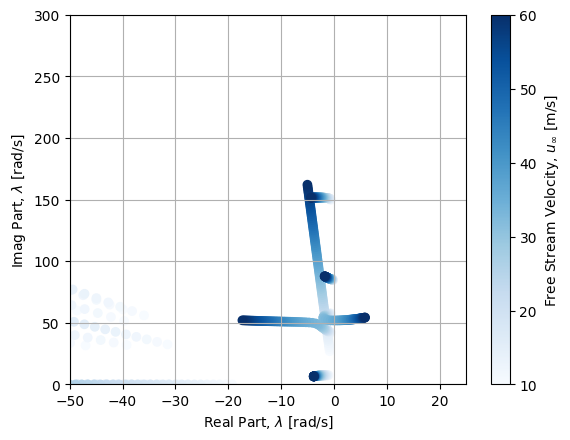

In [268]:
file_name = './output/%s/stability/velocity_analysis_min0100_max0600_nvel0081.dat' % case_name
%matplotlib inline
velocity_analysis = np.loadtxt(file_name)
u_inf = velocity_analysis[:, 0]
eigs_r = velocity_analysis[:, 1]
eigs_i = velocity_analysis[:, 2]

fig = plt.figure()
plt.scatter(eigs_r, eigs_i, c=u_inf, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label('Free Stream Velocity, $u_\infty$ [m/s]')

plt.grid()
plt.xlim(-50, 25)
plt.ylim(0, 300)
plt.xlabel('Real Part, $\lambda$ [rad/s]')
plt.ylabel('Imag Part, $\lambda$ [rad/s]');

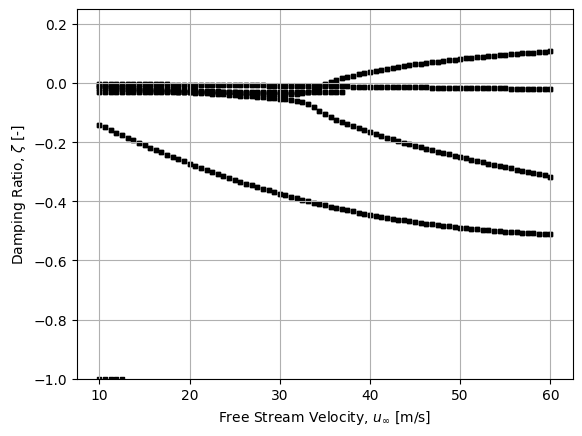

In [269]:
fig = plt.figure()
natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
damping_ratio = eigs_r / natural_frequency
cond = (eigs_r>-25) * (eigs_r<10) * (natural_frequency<100) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)

plt.grid()
plt.ylim(-1, 0.25)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Damping Ratio, $\zeta$ [-]');

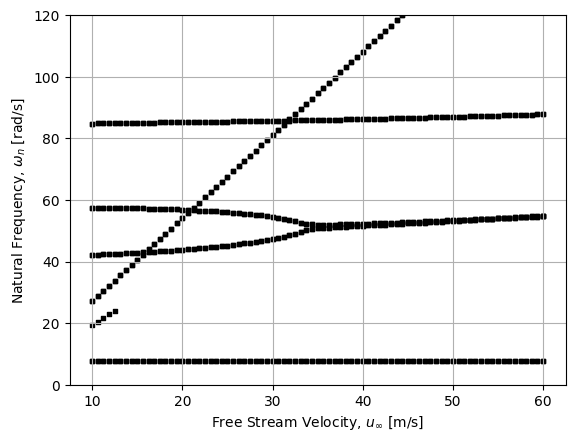

In [270]:
fig = plt.figure()
cond = (eigs_r>-25) * (eigs_r<10) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], natural_frequency[cond], color='k', marker='s', s=9)
plt.grid()
plt.ylim(0, 120)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Natural Frequency, $\omega_n$ [rad/s]');